In [22]:
def fix_mojibake(text):
    if not isinstance(text, str):
        return text
    try:
        import ftfy
        return ftfy.fix_text(text)
    except ImportError:
        # fallback: common case is UTF-8 bytes that got decoded as latin-1/cp1252
        try:
            return text.encode("latin-1").decode("utf-8")
        except (UnicodeDecodeError, UnicodeEncodeError):
            return text

In [1]:
def distribution_stats(values):
    import numpy as np
    from scipy import stats as sstats
    s = np.asarray(values, dtype=float)
    s = s[~np.isnan(s)]
    out = {
        "n": len(s), "min": s.min(), "max": s.max(),
        "mean": s.mean(), "median": np.median(s),
        "skew": sstats.skew(s), "kurtosis": sstats.kurtosis(s),
        "pct_zero": (s == 0).mean() * 100,
        "pct_negative": (s < 0).mean() * 100,
        "pct_positive": (s > 0).mean() * 100,
        "percentiles": {p: np.percentile(s, p) for p in [5, 10, 25, 50, 75, 90, 95, 99]},
    }
    out["flags"] = []
    if abs(out["skew"]) > 10:
        out["flags"].append("severe skew")
    elif abs(out["skew"]) > 2:
        out["flags"].append("notable skew")
    if out["kurtosis"] > 100:
        out["flags"].append("extreme kurtosis")
    if out["pct_zero"] > 10:
        out["flags"].append("large zero spike")
    return out

In [3]:
def jenks_breaks(values, n_classes):
    import jenkspy
    import numpy as np
    s = np.asarray(values, dtype=float)
    s = s[~np.isnan(s)]
    if len(np.unique(s)) < n_classes + 1:
        n_classes = max(1, len(np.unique(s)) - 1)
    breaks = sorted(set(jenkspy.jenks_breaks(s, n_classes=n_classes)))
    actual_classes = len(breaks) - 1
    return {"breaks": breaks, "requested_classes": n_classes,
            "actual_classes": actual_classes, "degenerate": actual_classes < n_classes}

In [12]:
def round_pretty_breaks(breaks, threshold=200, keep_ends_unrounded=True):
    def snap(x):
        if x == 0:
            return 0.0
        step = 50 if abs(x) <= threshold else 100
        return round(x / step) * step
    rounded = [snap(b) for b in breaks]
    if keep_ends_unrounded:
        rounded[0], rounded[-1] = breaks[0], breaks[-1]
    collisions = [i for i in range(len(rounded) - 1) if rounded[i] == rounded[i + 1]]
    return {"rounded": rounded, "collisions": collisions}

In [5]:
def assign_colors(n_classes, side, blues=None, reds=None):
    if blues is None:
        blues = ["#005580", "#06739C", "#0A94B2", "#12B4C8", "#4DCBD8", "#89E1E9", "#D9FFFF"]
    if reds is None:
        reds = ["#FFFFD9", "#FDCC81", "#FCA446", "#FB8011", "#DD570E", "#BF2E0E", "#A70E0E"]
    if side == "blue":
        return blues[len(blues) - n_classes:]   # most extreme -> nearest midpoint
    elif side == "red":
        return reds[:n_classes]                 # nearest midpoint -> most extreme
    else:
        raise ValueError("side must be 'blue' or 'red'")

In [6]:
def render_legend_html(breaks, colors, labels=None, bar_width_px=280, no_data_color=None, no_data_label=None):
    import math
    if labels is None:
        labels = [str(b) for b in breaks]
    widths = [math.sqrt(breaks[i+1] - breaks[i]) for i in range(len(breaks) - 1)]
    total = sum(widths)
    pcts = [w / total * 100 for w in widths]
    segments = "".join(
        f'<span style="display:inline-block; width:{p:.4f}%; height:20px; background:{c}; vertical-align:top;"></span>'
        for p, c in zip(pcts, colors)
    )
    cumulative = [0]
    for p in pcts:
        cumulative.append(cumulative[-1] + p)
    label_spans = "".join(
        f'<span style="position:absolute; left:{cum:.4f}%; transform:translateX(-50%); font-size:11px;">{lab}</span>'
        for cum, lab in zip(cumulative, labels)
    )
    html = f'''<div style="font-family:sans-serif; padding:8px 12px; display:inline-block;">
  <div style="line-height:0; font-size:0; width:{bar_width_px}px;">{segments}</div>
  <div style="position:relative; width:{bar_width_px}px; padding-top:4px; height:16px;">{label_spans}</div>
</div>'''
    if no_data_color:
        html += f'''
<div style="font-family:sans-serif; padding:8px 12px; margin-left:12px; display:inline-block;">
  <div style="width:24px; height:20px; background:{no_data_color};"></div>
  <div style="padding-top:4px; font-size:11px;">{no_data_label or "No data"}</div>
</div>'''
    return html

In [7]:
def render_excel_formula(breaks, colors, cell="A2", legacy=False):
    interior_breaks = breaks[1:-1]
    conditions = list(zip(interior_breaks, colors[:-1]))
    last_color = colors[-1]
    if not legacy:
        parts = [f'{cell}<{b},"{c}"' for b, c in conditions]
        parts.append(f'TRUE,"{last_color}"')
        return "=IFS(\n" + ",\n".join(parts) + ")"
    else:
        formula = f'"{last_color}"'
        for b, c in reversed(conditions):
            formula = f'IF({cell}<{b},"{c}",{formula})'
        return f"={formula}"

In [8]:
def render_hex_list(colors):
    return "\n".join(f"{c}: {c}" for c in colors)

In [23]:
import pandas as pd

df = pd.read_csv('/home/emily_zuetell/projects/poreallas/analysis/v3_map.csv')
months = ['Sep 2026', 'Oct', 'Nov', 'Dec', 'Jan 2027', 'Feb']

# Pool positive values across all month columns so every map shares one scale
pooled_pos = pd.concat([df[m] for m in months])
pooled_pos = pooled_pos[pooled_pos > 0]

stats = distribution_stats(pooled_pos)

jenks = jenks_breaks(pooled_pos, n_classes=6)

pretty = round_pretty_breaks(jenks["breaks"])
breaks = pretty["rounded"]

colors = assign_colors(n_classes=len(breaks) - 1, side="red")

# values <=0 fall outside the sequential scale -> flagged as no-data (adjust color/label as needed)
no_data_color = "#CCCCCC"

for m in months:
    col = f"{m}_color"
    df[col] = pd.cut(df[m], bins=breaks, labels=colors, include_lowest=True).astype(str)
    df.loc[df[m] <= 0, col] = no_data_color

df["NAME_1"] = df["NAME_1"].apply(fix_mojibake)
df["name"] = df["name"].apply(fix_mojibake)

df.to_csv('v3_map_colored.csv', index=False)

legend_html = render_legend_html(breaks, colors, no_data_color=no_data_color, no_data_label="0 or negative")
with open('flourish_legend.html', 'w') as f:
    f.write(legend_html)

In [25]:
breaks

[np.float64(1.0), 50, 100, 300, 600, 1300, np.float64(2400.0)]

In [10]:
colors

['#FFFFD9', '#FDCC81', '#FCA446', '#FB8011', '#DD570E', '#BF2E0E']

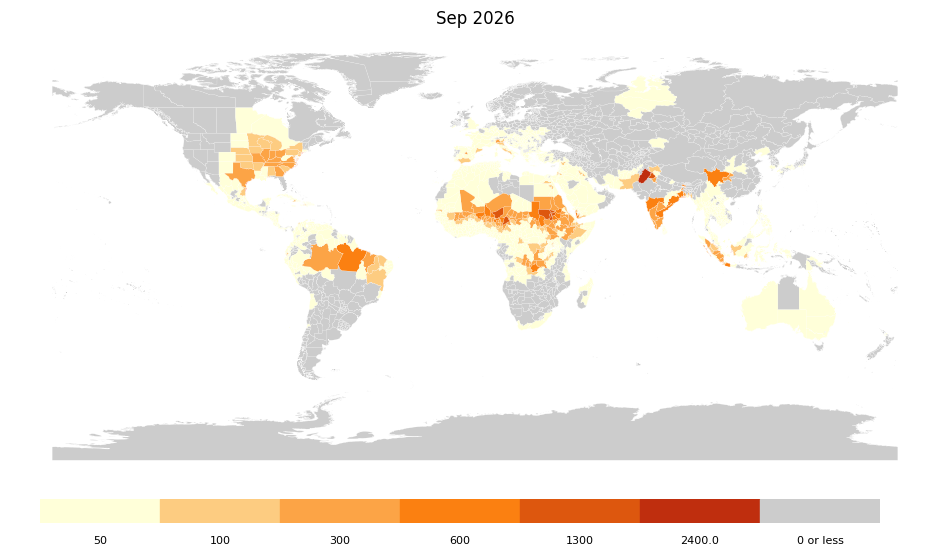

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

gdf = gpd.read_parquet("/home/emily_zuetell/projects/poreallas/data/adm1.parquet")
gdf = gdf.merge(df, on="GID_1", how="left")

fig, ax = plt.subplots(figsize=(12, 6))
gdf.plot(color=gdf["Sep 2026_color"].fillna(no_data_color), edgecolor="white", linewidth=0.1, ax=ax)
ax.axis("off")
ax.set_title("Sep 2026")

# legend: one swatch per bin, plus no-data
legend_ax = fig.add_axes([0.15, 0.05, 0.7, 0.04])
legend_ax.axis("off")
n = len(colors) + 1
labels = breaks[1:] + ["0 or less"]
swatches = colors + [no_data_color]
for i, (color, label) in enumerate(zip(swatches, labels)):
    legend_ax.add_patch(Rectangle((i / n, 0), 1 / n, 1, color=color, transform=legend_ax.transAxes))
    legend_ax.text((i + 0.5) / n, -0.5, str(label), ha="center", va="top",
                    fontsize=8, transform=legend_ax.transAxes)

plt.savefig("map_preview_sep2026.png", dpi=150, bbox_inches="tight")